/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  0.9561
Precision: 0.9459
Recall:    0.9859
F1 Score:  0.9655
AUC-ROC:   0.9984
AUC-PR:    0.9990


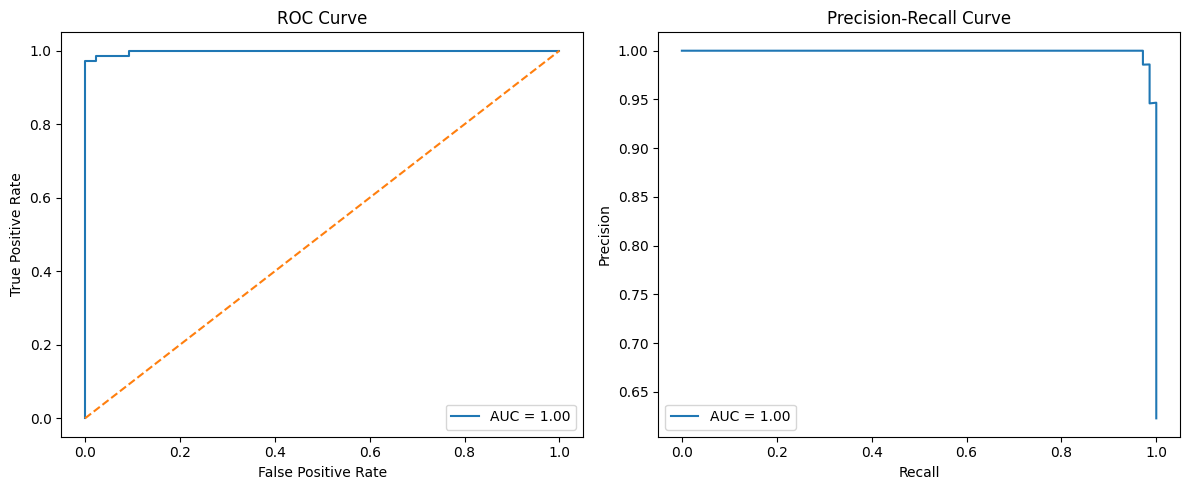

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
   accuracy_score, precision_score, recall_score, f1_score,
   roc_auc_score, roc_curve, precision_recall_curve, auc
)
from sklearn.model_selection import train_test_split
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train logistic regression model
model = LogisticRegression() # it will stop fitting at 100 iterations 
model.fit(X_train, y_train)
# Predict probabilities and labels
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC and PR curves (values between 0 and 1)
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_probs)
# Precision-Recall AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
auc_pr = auc(recall_vals, precision_vals)
# Print metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print(f"AUC-PR:    {auc_pr:.4f}")
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_vals, precision_vals, label=f"AUC = {auc_pr:.2f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif # this is for classification tasks
# from sklearn.feature_selection import mutual_info_regression # this is for regression tasks
# Apply Information Gain. ig contains an array of importance scores — one for each feature.
ig = mutual_info_classif(X, y) # information gain scores for each feature
# Create a dictionary of feature importance scores
feature_scores = {}
for i in range(len(data.feature_names)):
    feature_scores[data.feature_names[i]] = ig[i]
# Sort the features by importance score in descending order
sorted_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)
# Print the feature importance scores and the sorted features
for feature, score in sorted_features:
    print("Feature:", feature, "Score:", score)

Feature: worst perimeter Score: 0.47587069862811315
Feature: worst area Score: 0.46340525985073944
Feature: worst radius Score: 0.452751148296737
Feature: mean concave points Score: 0.44067933677764026
Feature: worst concave points Score: 0.43729985608104904
Feature: mean perimeter Score: 0.404727893945259
Feature: mean concavity Score: 0.3754067940253838
Feature: mean radius Score: 0.3691635749306479
Feature: mean area Score: 0.3617425072230054
Feature: area error Score: 0.34120126118134886
Feature: worst concavity Score: 0.3170396881684965
Feature: perimeter error Score: 0.27379082215415584
Feature: radius error Score: 0.24653417542832812
Feature: worst compactness Score: 0.22446646577182383
Feature: mean compactness Score: 0.21049252176369104
Feature: concave points error Score: 0.12786620372032353
Feature: worst texture Score: 0.12380652284077431
Feature: concavity error Score: 0.11735823382389787
Feature: worst smoothness Score: 0.09746134304669796
Feature: mean texture Score: 0.0

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

Selected Features: ('0', '4', '21', '22', '25')
Accuracy: 0.956043956043956


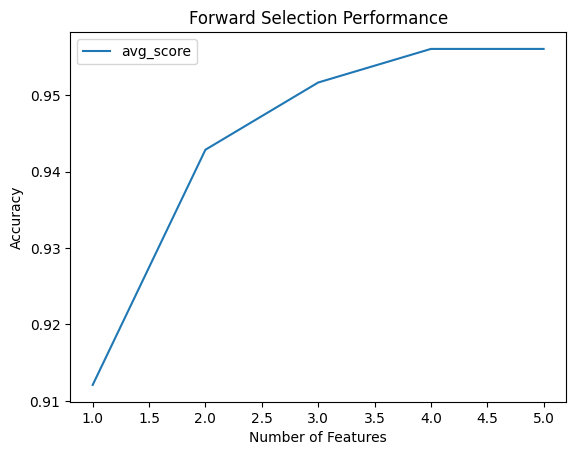

In [ ]:
import pandas as pd 
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
# Define the forward selection object with only 5 features.
sfs = SFS(model, k_features=5, forward=True, floating=False, scoring="accuracy", cv=5)
# Perform forward selection on the training set
sfs.fit(X_train, y_train)
# Print the selected features
print("Selected Features:", sfs.k_feature_names_)
# Evaluate the performance of the selected features on the testing set
accuracy = sfs.k_score_
print("Accuracy:", accuracy)
# Plot the performance of the model with different feature subsets
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sfs_df["avg_score"] = sfs_df["avg_score"].astype(float)
fig, ax = plt.subplots()
sfs_df.plot(kind="line", y="avg_score", ax=ax)
ax.set_xlabel("Number of Features")
ax.set_ylabel("Accuracy")
ax.set_title("Forward Selection Performance")
plt.show()